# 🎾 Padel Analytics — Machine Learning Project
## Étape 1 : Data Preparation & Feature Engineering

| Info | Détail |
|------|--------|
| **Base de données** | `dw_padel_analytics` (MySQL / phpMyAdmin) |
| **Tables Faits** | `fact_performance`, `fact_equipement` |
| **Tables Dimensions** | `dim_player_ofc`, `dim_padel_info`, `dim_date`, `dim_countryy`, `dim_gender`, `dim_tournmant`, `dim_type_match`, `dim_vendor`, `dim_team_ofc` |
| **Objectif ML** | Prédire le **résultat d'un match** (Win = 1 / Loss = 0) |

---
## 📦 0. Installation des dépendances
> Exécuter cette cellule une seule fois si les packages ne sont pas installés.

In [11]:
!pip install mysql-connector-python

In [12]:
# Décommenter et exécuter si nécessaire
# !pip install mysql-connector-python sqlalchemy pandas numpy matplotlib seaborn scikit-learn

---
## 📚 1. Import des bibliothèques

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Toutes les bibliothèques sont importées avec succès.')

✅ Toutes les bibliothèques sont importées avec succès.


---
## 🔌 2. Connexion à MySQL (phpMyAdmin / XAMPP)

> **Prérequis :** XAMPP doit être lancé avec le service **MySQL actif**.  
> Vérifier sur `http://localhost/phpmyadmin` que la base `dw_padel_analytics` existe.

In [16]:
DB_USER     = 'root'
DB_PASSWORD = ''
DB_HOST     = 'localhost'
DB_PORT     = '3306'
DB_NAME     = 'dw_padel_analytics'

engine = create_engine(
    f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    echo=False
)

try:
    with engine.connect() as conn:
        result = conn.execute(text('SELECT DATABASE()'))
        db_name = result.fetchone()[0]
    print(f'✅ Connexion réussie ! Base active : {db_name}')
except Exception as e:
    print(f'❌ Erreur : {e}')

✅ Connexion réussie ! Base active : dw_padel_analytics


---
## 📥 3. Chargement des tables

In [18]:
print('📥 Chargement des tables...')

fact_perf   = pd.read_sql('SELECT * FROM fact_performance', engine)
fact_equip  = pd.read_sql('SELECT * FROM fact_equipement',  engine)
dim_player  = pd.read_sql('SELECT * FROM dim_player_ofc',   engine)
dim_padel   = pd.read_sql('SELECT * FROM dim_padel_info',   engine)
dim_date    = pd.read_sql('SELECT * FROM dim_date',         engine)
dim_country = pd.read_sql('SELECT * FROM dim_countryy',     engine)
dim_gender  = pd.read_sql('SELECT * FROM dim_gender',       engine)
dim_tourn   = pd.read_sql('SELECT * FROM dim_tournmant',    engine)
dim_type    = pd.read_sql('SELECT * FROM dim_type_match',   engine)
dim_vendor  = pd.read_sql('SELECT * FROM dim_vendor',       engine)
dim_team    = pd.read_sql('SELECT * FROM dim_team_ofc',     engine)

print('✅ CHARGEMENT TERMINÉ ! 🎉')

📥 Chargement des tables...
✅ CHARGEMENT TERMINÉ ! 🎉


In [19]:
import pandas as pd
print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.2


In [20]:
!pip install --force-reinstall numpy==1.26.4 --no-deps

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.


In [21]:
import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 1.26.4


In [22]:
!pip install pandas==2.2.2 --force-reinstall

  Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl (11.5 MB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
Using cached tzdata-2026.1-py2.py3-none-any.whl (348 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.1.post1
    Uninstalling pytz-2026.1.post1:
      Successfully uninstalled pytz-2026.1.post1
  Attempting uninstall: tzdata
    Found e

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.4 which is incompatible.


---
## 🔍 4. Exploration initiale (EDA)

In [25]:
print('=== fact_performance — Aperçu ===')
display(fact_perf.head(5))
print(f'\nShape : {fact_perf.shape}')
print('\nTypes :')
print(fact_perf.dtypes)

=== fact_performance — Aperçu ===


,DateKey,Id_gender,Id_type_match,Id_tr_name,Id_Fact,Score,Points__Loser,Points__Winner,Id_Country_player1_winner,Id_Country_player2_winner,Id_Player_1_winner,Id_Player_2_winner,Id_Player_1_loser,Id_Player_2_loser,Id_Country_player1_loser,Id_Country_player2_loser,Prize__Winner,Prize__Loser,Tournament_Name,Date,Id_team_Loser,Id_team_Winner
0,20230308,1683,1781,6640,1,67(4) 75 60,0,1,1692,1692,2617,2704,0,3798,0,1751,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1102,12
1,20230308,1683,1781,6640,2,75 62,0,1,1692,1692,2665,2611,4197,3432,1685,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1103,13
2,20230308,1683,1781,6640,3,62 76(5),0,1,1695,1695,3487,3579,0,3224,0,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1104,14
3,20230308,1683,1781,6640,4,63 76,0,1,1697,1685,5217,2812,0,0,0,0,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1105,15
4,20230308,1683,1781,6640,5,75 62,0,1,1695,1685,2924,3051,3060,3063,1721,1721,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1106,16



Shape : (1538, 22)

Types :
DateKey                               int64
Id_gender                             int64
Id_type_match                         int64
Id_tr_name                            int64
Id_Fact                               int64
Score                                object
Points__Loser                         int64
Points__Winner                        int64
Id_Country_player1_winner             int64
Id_Country_player2_winner             int64
Id_Player_1_winner                    int64
Id_Player_2_winner                    int64
Id_Player_1_loser                     int64
Id_Player_2_loser                     int64
Id_Country_player1_loser              int64
Id_Country_player2_loser              int64
Prize__Winner                        object
Prize__Loser                          int64
Tournament_Name                      object
Date                         datetime64[ns]
Id_team_Loser                         int64
Id_team_Winner                        int64
dty

In [26]:
print('=== dim_player_ofc — Aperçu ===')
display(dim_player.head(5))

print('\n=== dim_padel_info — Aperçu ===')
display(dim_padel.head(5))

=== dim_player_ofc — Aperçu ===


,Name,Points,Position,Move,Genre,Id_Country,Id_Player,Level
0,ARTURO COELLO,19800.00,1.00,0.00,Male,1685,2522,Professional
1,AGUSTIN TAPIA,19800.00,1.00,0.00,Male,1686,2523,Professional
2,ALEJANDRO GALAN,17320.00,3.00,0.00,Male,1685,2524,Professional
3,FEDERICO CHINGOTTO,17320.00,3.00,0.00,Male,1686,2525,Professional
4,FRANCO STUPACZUK,7905.00,5.00,0.00,Male,1686,2526,Professional



=== dim_padel_info — Aperçu ===


,title,handle,product_type,tags,created_at,sku,Id_Padel,image,weight,shape,foam,collection,game_level,frame,surface,color,racket_type,balance,racket_cover
0,Raquette de padel Babolat Air Viper 2025,raquette-de-padel-babolat-air-viper-2025,Raquettes,tout,2024-12-18,8732,1792,https://cdn.shopify.com/s/files/1/0430/1861/69...,340-355g,diamant,EVA Soft,2025,expert,carbone,sand,bleu,attaque,haut,Oui
1,Raquette de padel Head Vibe Vert 2026,raquette-de-padel-head-vibe-vert-2026,Raquettes,"fait, tout",2026-01-08,12204,1793,https://cdn.shopify.com/s/files/1/0430/1861/69...,355-370g,ronde,EVA Soft,2026,débutant,carbone,sand,vert,polyvalente,milieu,Non
2,Raquette de padel Starvie Nyra 2026,raquette-de-padel-starvie-nyra-2026,Raquettes,"fait, tout",2026-01-02,12082,1794,https://cdn.shopify.com/s/files/1/0430/1861/69...,355-370g,ronde,EVA Soft,2026,intermédiaire,carbone,sand,multicolore,polyvalente,milieu,Non
3,Raquette de padel Starvie Arkos 2026,raquette-de-padel-starvie-arkos-2026,Raquettes,"fait, tout",2026-01-02,12081,1795,https://cdn.shopify.com/s/files/1/0430/1861/69...,355-370g,ronde,EVA Soft,2026,intermédiaire,carbone,sand,bleu,polyvalente,milieu,Non
4,Raquette de padel Starvie Polaris 2026,raquette-de-padel-starvie-polaris-2026,Raquettes,"fait, tout",2025-12-31,12080,1796,https://cdn.shopify.com/s/files/1/0430/1861/69...,355-370g,ronde,EVA Soft,2026,intermédiaire,carbone,sand,multicolore,polyvalente,milieu,Oui


In [27]:
print('=== Statistiques descriptives — fact_performance ===')
display(fact_perf.describe(include='all'))

=== Statistiques descriptives — fact_performance ===


,DateKey,Id_gender,Id_type_match,Id_tr_name,Id_Fact,Score,Points__Loser,Points__Winner,Id_Country_player1_winner,Id_Country_player2_winner,Id_Player_1_winner,Id_Player_2_winner,Id_Player_1_loser,Id_Player_2_loser,Id_Country_player1_loser,Id_Country_player2_loser,Prize__Winner,Prize__Loser,Tournament_Name,Date,Id_team_Loser,Id_team_Winner
count,1538.00,1538.00,1538.00,1538.00,1538.00,1537,1538.00,1538.00,1538.00,1538.00,1538.00,1538.00,1538.00,1538.00,1538.00,1538.00,1538,1538.00,1538,1538,1538.00,1538.00
unique,NaN,NaN,NaN,NaN,NaN,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72,NaN,80,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,62 62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,PARIS MAJOR PREMIER PADEL,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,709,NaN,88,NaN,NaN,NaN
mean,20241672.81,1683.49,1782.54,6676.79,769.50,NaN,30.06,63.58,904.28,875.28,1743.05,1671.70,1664.32,1609.57,843.22,822.21,NaN,793.93,NaN,2024-07-22 22:05:46.423927296,786.43,613.81
min,20230106.00,1683.00,1781.00,6640.00,1.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,2023-01-06 00:00:00,12.00,12.00
25%,20230709.00,1683.00,1781.00,6655.00,385.25,NaN,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,2023-07-09 00:00:00,341.25,273.00
50%,20240813.00,1683.00,1782.00,6669.00,769.50,NaN,1.00,14.00,1685.00,1685.00,2530.00,2530.00,0.00,0.00,0.00,0.00,NaN,0.00,NaN,2024-08-13 00:00:00,756.50,564.00
75%,20250614.00,1684.00,1783.00,6688.00,1153.75,NaN,25.00,90.00,1685.00,1685.00,2628.75,2617.00,2645.50,2643.00,1685.00,1685.00,NaN,0.00,NaN,2025-06-14 00:00:00,1208.75,913.75
max,20251214.00,1684.00,1788.00,6731.00,1538.00,NaN,1200.00,2000.00,1769.00,1727.00,6613.00,6263.00,6613.00,6551.00,1769.00,1751.00,NaN,76375.00,NaN,2025-12-14 00:00:00,1654.00,1650.00


---
## 🔗 5. Jointures — Construction du Dataset ML

In [29]:
df = fact_perf.copy()

# Jointure dim_date
df = df.merge(
    dim_date[['DateKey', 'Year', 'Month', 'Quarter', 'IsWeekend', 'DayOfWeekName']],
    on='DateKey', how='left'
)

# Jointure dim_gender
df = df.merge(dim_gender, on='Id_gender', how='left')

# Jointure dim_type_match
df = df.merge(dim_type, on='Id_type_match', how='left')

# Jointure dim_player (joueur 1 gagnant)
p1w = dim_player.rename(columns={
    'Id_Player': 'Id_Player_1_winner',
    'Points'   : 'Points_P1W',
    'Position' : 'Position_P1W',
    'Move'     : 'Move_P1W',
    'Level'    : 'Level_P1W',
    'Name'     : 'Name_P1W',
    'Genre'    : 'Genre_P1W',
    'Id_Country': 'IdC_P1W'
})
df = df.merge(
    p1w[['Id_Player_1_winner', 'Points_P1W', 'Position_P1W', 'Level_P1W']],
    on='Id_Player_1_winner', how='left'
)

# Jointure dim_player (joueur 1 perdant)
p1l = dim_player.rename(columns={
    'Id_Player': 'Id_Player_1_loser',
    'Points'   : 'Points_P1L',
    'Position' : 'Position_P1L',
    'Move'     : 'Move_P1L',
    'Level'    : 'Level_P1L',
    'Name'     : 'Name_P1L',
    'Genre'    : 'Genre_P1L',
    'Id_Country': 'IdC_P1L'
})
df = df.merge(
    p1l[['Id_Player_1_loser', 'Points_P1L', 'Position_P1L', 'Level_P1L']],
    on='Id_Player_1_loser', how='left'
)

print(f'✅ Dataset après jointures : {df.shape}')
display(df.head(3))

✅ Dataset après jointures : (1538, 35)


,DateKey,Id_gender,Id_type_match,Id_tr_name,Id_Fact,Score,Points__Loser,Points__Winner,Id_Country_player1_winner,Id_Country_player2_winner,Id_Player_1_winner,Id_Player_2_winner,Id_Player_1_loser,Id_Player_2_loser,Id_Country_player1_loser,Id_Country_player2_loser,Prize__Winner,Prize__Loser,Tournament_Name,Date,Id_team_Loser,Id_team_Winner,Year,Month,Quarter,IsWeekend,DayOfWeekName,Gender,Match_type,Points_P1W,Position_P1W,Level_P1W,Points_P1L,Position_P1L,Level_P1L
0,20230308,1683,1781,6640,1,67(4) 75 60,0,1,1692,1692,2617,2704,0,3798,0,1751,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1102,12,2023,3,1,0,Wednesday,Male,Round of 32,694.00,96.00,Intermediate,NaN,NaN,NaN
1,20230308,1683,1781,6640,2,75 62,0,1,1692,1692,2665,2611,4197,3432,1685,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1103,13,2023,3,1,0,Wednesday,Male,Round of 32,384.00,144.00,Beginner,5.00,1616.00,Beginner
2,20230308,1683,1781,6640,3,62 76(5),0,1,1695,1695,3487,3579,0,3224,0,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1104,14,2023,3,1,0,Wednesday,Male,Round of 32,15.00,959.00,Beginner,NaN,NaN,NaN


---
## 🧹 6. Data Cleaning
### 6.1 Valeurs manquantes

📋 Colonnes avec valeurs manquantes :


,Missing,Percentage (%)
Points_P1L,770,50.07
Position_P1L,770,50.07
Level_P1L,770,50.07
Points_P1W,714,46.42
Position_P1W,714,46.42
Level_P1W,714,46.42
Score,1,0.07


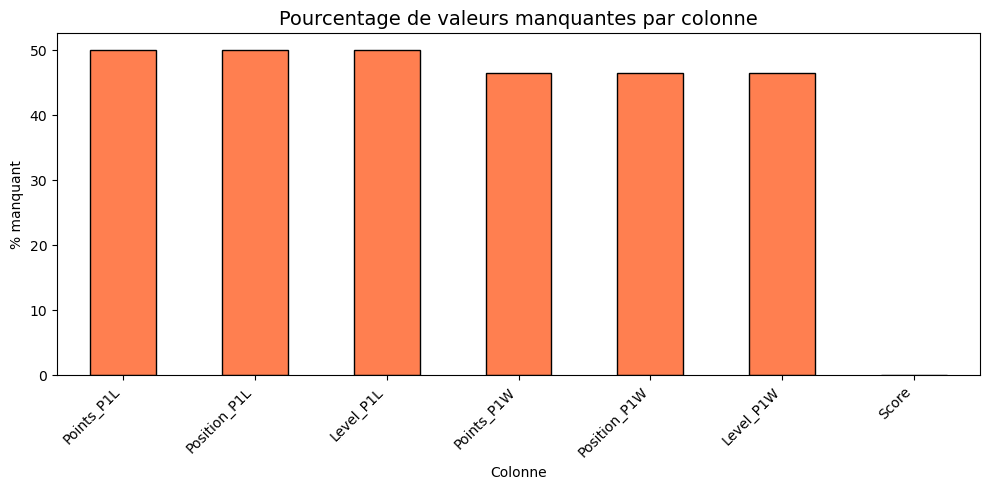

In [31]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage (%)', ascending=False)

print('📋 Colonnes avec valeurs manquantes :')
display(missing_df)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Percentage (%)'].plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=14)
    ax.set_ylabel('% manquant')
    ax.set_xlabel('Colonne')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Aucune valeur manquante détectée.')

### 6.2 Traitement des valeurs manquantes

In [33]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print(f'✅ Valeurs manquantes après traitement : {df.isnull().sum().sum()}')

✅ Valeurs manquantes après traitement : 1


### 6.3 Détection et traitement des outliers (méthode IQR)

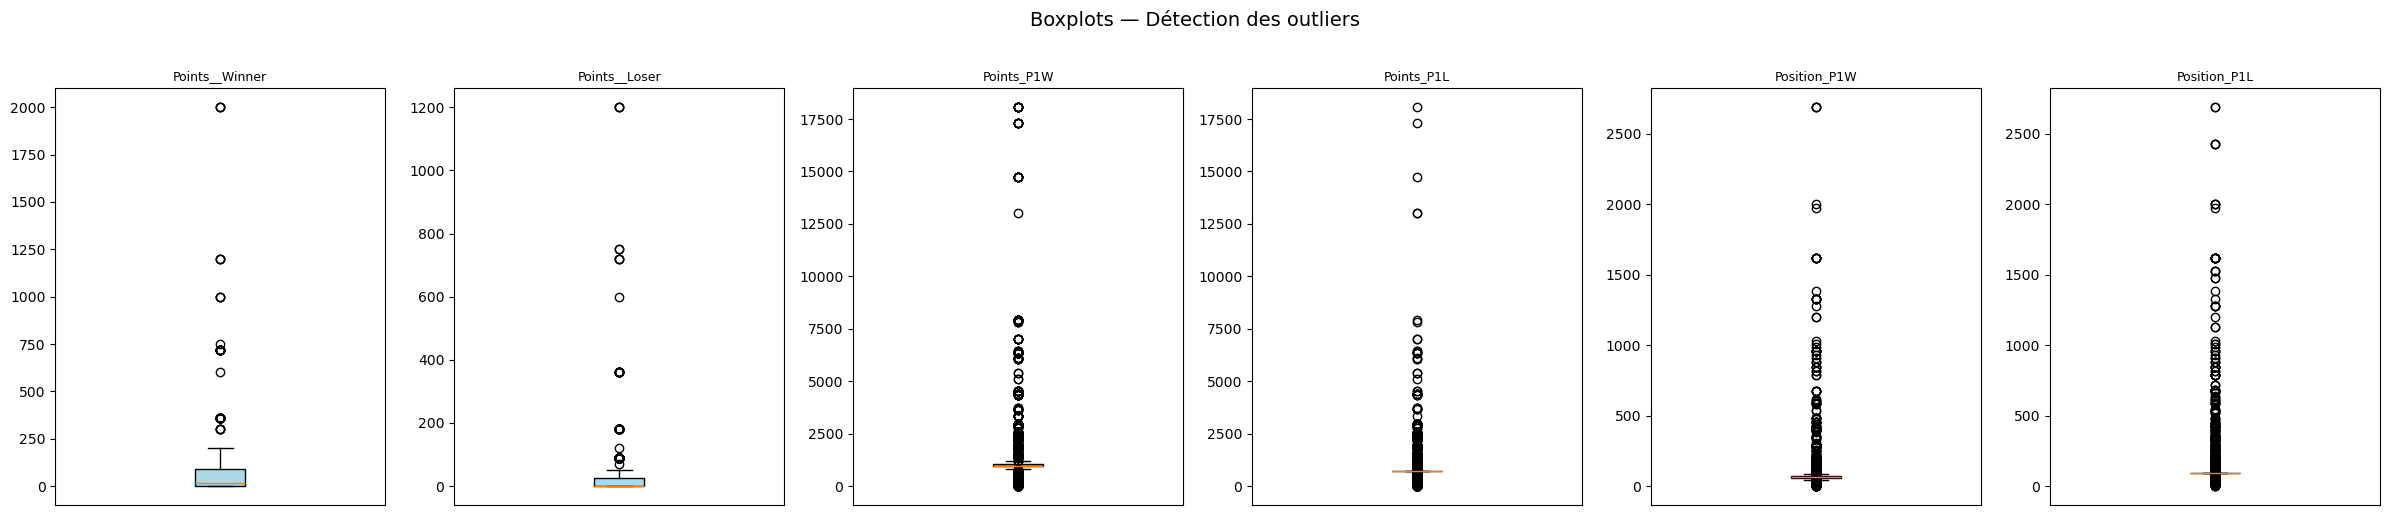

✅ Outliers traités par capping IQR.


In [35]:
outlier_cols = ['Points__Winner', 'Points__Loser', 'Points_P1W', 'Points_P1L',
                'Position_P1W', 'Position_P1L']
outlier_cols = [c for c in outlier_cols if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4 * len(outlier_cols), 5))
if len(outlier_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

plt.suptitle('Boxplots — Détection des outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

def cap_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

for col in outlier_cols:
    df[col] = cap_outliers_iqr(df[col])

print('✅ Outliers traités par capping IQR.')

---
## ⚙️ 7. Feature Engineering
### 7.1 Variable cible (Target)

✅ Dataset ML shape : (3076, 39)

Distribution de la variable cible :
target
1    1538
0    1538
Name: count, dtype: int64


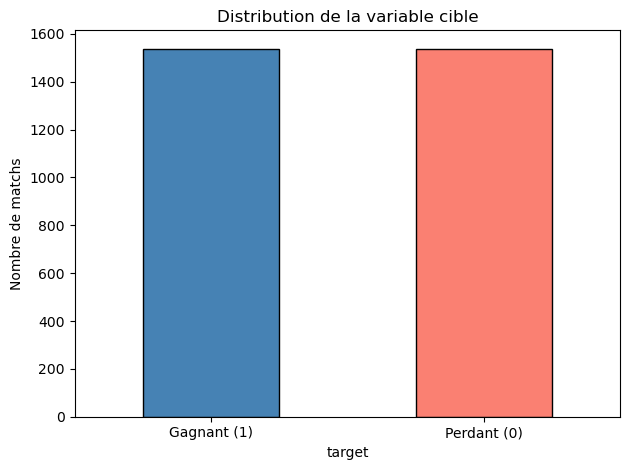

In [37]:
# Chaque ligne = un match — on crée 2 perspectives : Winner (1) et Loser (0)
winners = df.copy()
winners['target']        = 1
winners['Points_team']   = winners['Points__Winner']
winners['Position_team'] = winners['Position_P1W']
winners['Level_team']    = winners['Level_P1W']

losers = df.copy()
losers['target']        = 0
losers['Points_team']   = losers['Points__Loser']
losers['Position_team'] = losers['Position_P1L']
losers['Level_team']    = losers['Level_P1L']

ml_df = pd.concat([winners, losers], ignore_index=True)

print(f'✅ Dataset ML shape : {ml_df.shape}')
print('\nDistribution de la variable cible :')
print(ml_df['target'].value_counts())

ml_df['target'].value_counts().plot(
    kind='bar', color=['steelblue', 'salmon'], edgecolor='black'
)
plt.xticks([0, 1], ['Gagnant (1)', 'Perdant (0)'], rotation=0)
plt.title('Distribution de la variable cible')
plt.ylabel('Nombre de matchs')
plt.tight_layout()
plt.show()

### 7.2 Création de nouvelles features

In [39]:
# Différence de points entre les deux équipes
ml_df['points_diff']   = ml_df['Points__Winner'] - ml_df['Points__Loser']

# Différence de classement
ml_df['position_diff'] = ml_df['Position_P1W'] - ml_df['Position_P1L']

# Nombre de sets joués (parsing du champ Score)
ml_df['nb_sets'] = ml_df['Score'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else np.nan
)

# Match en 3 sets = match serré
ml_df['is_3sets'] = (ml_df['nb_sets'] == 3).astype(int)

# Saison
if 'Quarter' in ml_df.columns:
    ml_df['season'] = ml_df['Quarter'].map({1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'})

new_feats = ['points_diff', 'position_diff', 'nb_sets', 'is_3sets']
if 'season' in ml_df.columns:
    new_feats.append('season')

print('✅ Nouvelles features créées :')
display(ml_df[new_feats].head(5))

✅ Nouvelles features créées :


,points_diff,position_diff,nb_sets,is_3sets,season
0,1.00,-3.50,3.00,1,Winter
1,1.00,-3.50,2.00,0,Winter
2,1.00,-3.50,2.00,0,Winter
3,1.00,-3.50,2.00,0,Winter
4,1.00,-3.50,2.00,0,Winter


---
## 🔡 8. Encodage des variables catégorielles

In [41]:
features = [
    'Points_team', 'Position_team',
    'points_diff', 'position_diff',
    'nb_sets', 'is_3sets',
    'Year', 'Month', 'Quarter', 'IsWeekend',
    'Gender', 'Match_type',
    'Level_P1W', 'Level_P1L'
]
features = [f for f in features if f in ml_df.columns]
print(f'Features sélectionnées ({len(features)}) : {features}')

X = ml_df[features].copy()
y = ml_df['target']

le = LabelEncoder()
cat_features = X.select_dtypes(include='object').columns.tolist()
print(f'\nColonnes à encoder : {cat_features}')

for col in cat_features:
    X[col] = le.fit_transform(X[col].astype(str))

print('✅ Encodage terminé.')
display(X.head(5))

Features sélectionnées (14) : ['Points_team', 'Position_team', 'points_diff', 'position_diff', 'nb_sets', 'is_3sets', 'Year', 'Month', 'Quarter', 'IsWeekend', 'Gender', 'Match_type', 'Level_P1W', 'Level_P1L']

Colonnes à encoder : ['Gender', 'Match_type', 'Level_P1W', 'Level_P1L']
✅ Encodage terminé.


,Points_team,Position_team,points_diff,position_diff,nb_sets,is_3sets,Year,Month,Quarter,IsWeekend,Gender,Match_type,Level_P1W,Level_P1L
0,1.00,87.50,1.00,-3.50,3.00,1,2023.00,3.00,1.00,0.00,1,4,1,0
1,1.00,87.50,1.00,-3.50,2.00,0,2023.00,3.00,1.00,0.00,1,4,0,0
2,1.00,87.50,1.00,-3.50,2.00,0,2023.00,3.00,1.00,0.00,1,4,0,0
3,1.00,87.50,1.00,-3.50,2.00,0,2023.00,3.00,1.00,0.00,1,4,0,0
4,1.00,87.50,1.00,-3.50,2.00,0,2023.00,3.00,1.00,0.00,1,4,0,0


---
## 📏 9. Normalisation (StandardScaler)

In [43]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('✅ Scaling appliqué (StandardScaler).')
display(X_scaled.describe().round(3))

✅ Scaling appliqué (StandardScaler).


,Points_team,Position_team,points_diff,position_diff,nb_sets,is_3sets,Year,Month,Quarter,IsWeekend,Gender,Match_type,Level_P1W,Level_P1L
count,3076.00,3076.00,3076.00,3076.00,3074.00,3076.00,3076.00,3076.00,3076.00,3076.00,3076.00,3076.00,3076.00,3076.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.60,-2.15,-0.70,-1.53,-1.53,-0.46,-1.28,-1.63,-1.30,-0.53,-1.03,-2.85,-1.97,-0.58
25%,-0.60,-0.71,-0.65,-0.41,-0.13,-0.46,-1.28,-0.68,-0.35,-0.53,-1.03,-0.54,-0.66,-0.58
50%,-0.51,0.66,-0.49,0.06,-0.13,-0.46,-0.12,-0.05,-0.35,-0.53,0.97,0.23,0.65,-0.58
75%,0.28,0.77,0.33,0.33,-0.13,-0.46,1.04,0.90,0.60,-0.53,0.97,0.23,0.65,0.91
max,3.74,0.77,2.94,1.44,5.46,2.20,1.04,1.85,1.56,1.89,0.97,2.53,0.65,2.40


---
## 🎯 10. Sélection de Features (Filter Method — Corrélation)

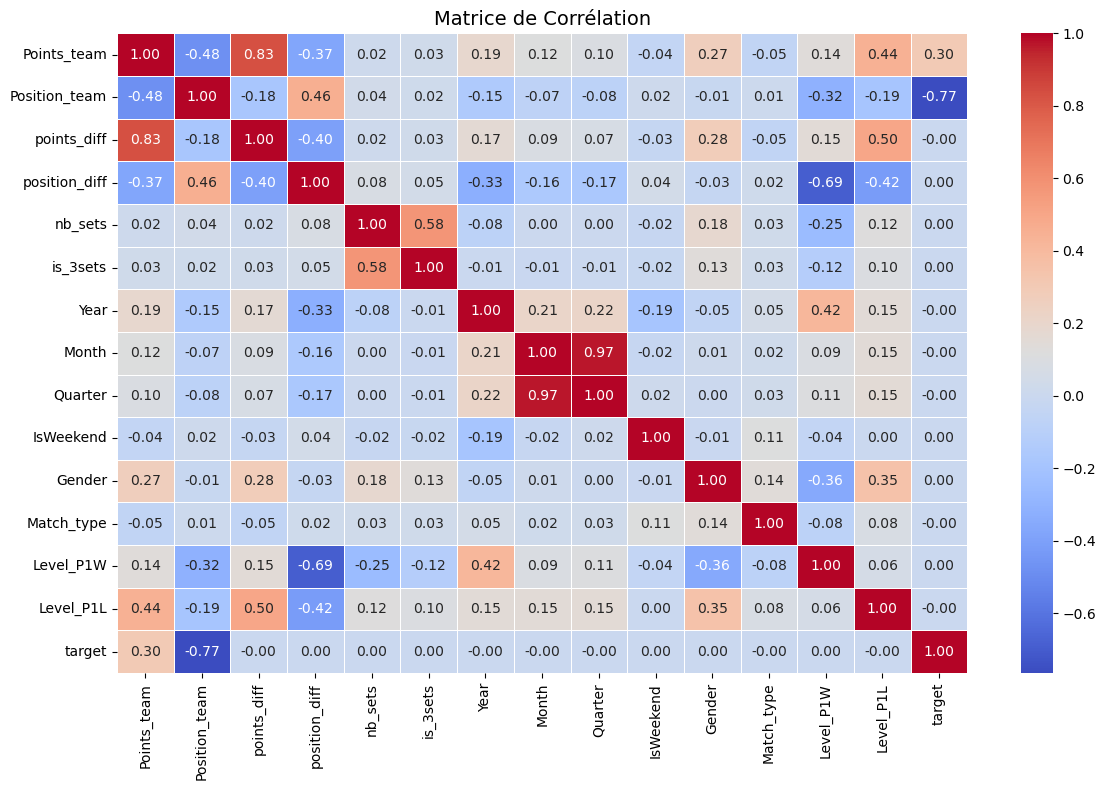


📊 Corrélation des features avec la variable cible :
Position_team   -0.77
Points_team      0.30
Year            -0.00
position_diff    0.00
Gender           0.00
IsWeekend        0.00
points_diff     -0.00
Level_P1L       -0.00
Month           -0.00
Quarter         -0.00
nb_sets          0.00
Level_P1W        0.00
is_3sets         0.00
Match_type      -0.00


In [45]:
corr_df = X_scaled.copy()
corr_df['target'] = y.values

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_df.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, ax=ax
)
ax.set_title('Matrice de Corrélation', fontsize=14)
plt.tight_layout()
plt.show()

target_corr = corr_df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print('\n📊 Corrélation des features avec la variable cible :')
print(target_corr.to_string())

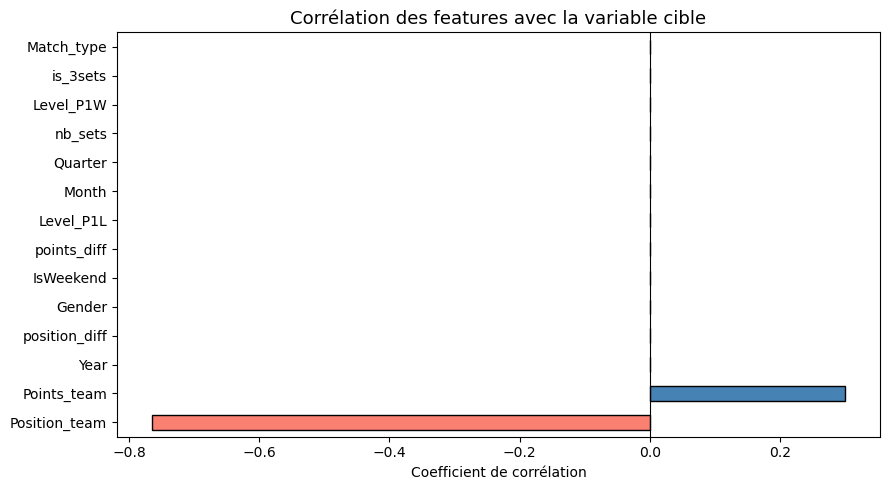


✅ Features sélectionnées (2) : ['Position_team', 'Points_team']


In [46]:
fig, ax = plt.subplots(figsize=(9, 5))
target_corr.plot(
    kind='barh', ax=ax,
    color=['steelblue' if v > 0 else 'salmon' for v in target_corr],
    edgecolor='black'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features avec la variable cible', fontsize=13)
ax.set_xlabel('Coefficient de corrélation')
plt.tight_layout()
plt.show()

# Garder uniquement les features avec |corr| > 0.05
selected_features = target_corr[target_corr.abs() > 0.05].index.tolist()
print(f'\n✅ Features sélectionnées ({len(selected_features)}) : {selected_features}')

---
## 💾 11. Sauvegarde du Dataset préparé

In [48]:
X_final = X_scaled[selected_features]

X_final.to_csv('X_padel_ml.csv', index=False)
y.to_csv('y_padel_ml.csv', index=False)

print('💾 Fichiers sauvegardés :')
print('   X_padel_ml.csv  →  features  :', X_final.shape)
print('   y_padel_ml.csv  →  target    :', y.shape)
print('\n🎉 Étape 1 terminée ! Prêt pour la modélisation (Étape 2).')

💾 Fichiers sauvegardés :
   X_padel_ml.csv  →  features  : (3076, 2)
   y_padel_ml.csv  →  target    : (3076,)

🎉 Étape 1 terminée ! Prêt pour la modélisation (Étape 2).


---
## 📋 Résumé de l'Étape 1

| Étape | Action | Méthode |
|-------|--------|---------|
| Connexion | MySQL via SQLAlchemy | `mysql+mysqlconnector` |
| Jointures | 11 tables liées | LEFT JOIN sur clés étrangères |
| Nettoyage | Valeurs manquantes | Médiane (num) / Mode (cat) |
| Outliers | Capping | IQR |
| Feature Eng. | Nouvelles variables | `points_diff`, `position_diff`, `nb_sets`, `is_3sets` |
| Encodage | Variables catégorielles | LabelEncoder |
| Scaling | Normalisation | StandardScaler |
| Sélection | Filter method | Corrélation (seuil 0.05) |

> ➡️ **Prochaine étape :** Modélisation ML (Random Forest, Logistic Regression, XGBoost…)